In [1]:
doc = 'you will never know until you try'

In [34]:
tokens = doc.split()
unique_tokens = set(tokens)
word2idx = {t: i for i, t in enumerate(unique_tokens)}

In [76]:
import numpy as np

vector_size = 4

# one_hot_vectors = np.zeros((len(tokens), len(word2idx)))
one_hot_vectors = np.eye(len(word2idx))
one_hot_vectors

W1 = np.random.random((len(word2idx), vector_size))
W1
W2 = np.random.random((vector_size, len(word2idx)))
W2

array([[0.53198601, 0.74362321, 0.68171461, 0.10587967, 0.44915306,
        0.32671503],
       [0.81632952, 0.19739304, 0.19486766, 0.17808171, 0.49531726,
        0.21440848],
       [0.27250203, 0.20041005, 0.95563563, 0.38131893, 0.51746728,
        0.89435795],
       [0.2927259 , 0.68428005, 0.71247004, 0.33032674, 0.52236463,
        0.04425199]])

In [18]:
# 학습데이터셋 만들기

[
    [('will'), 'you'],
    [('you', 'never'), 'will'],
] # 이 구조는 반복문을 한 번 더 써야하기 때문에 학습로직이 더러워질 수 있다.

[
    ['will', 'you'],

    ['you', 'will'],
    ['never', 'will'],
] # 이 구조는 X, y가 1:1로 대응하기 때문에 배치처리 로직같은걸 적용하기가 수월하다.

datas = []

window_size = 1
for i, target in enumerate(tokens):
    context_tokens = tokens[max(i-window_size, 0):i+1+window_size]
    # print(context_tokens)
    for token in context_tokens:
        if token == target: continue
        datas.append((token, target))

datas

[('will', 'you'),
 ('you', 'will'),
 ('never', 'will'),
 ('will', 'never'),
 ('know', 'never'),
 ('never', 'know'),
 ('until', 'know'),
 ('know', 'until'),
 ('you', 'until'),
 ('until', 'you'),
 ('try', 'you'),
 ('you', 'try')]

In [27]:
def softmax(vec):
    return np.exp(vec) / np.exp(vec).sum()

# 1. Feed Forward
for context, target in datas:
    X = one_hot_vectors[word2idx[context], :] # 6, 1차원 배열
    y_real = one_hot_vectors[word2idx[target], :] # 6, 1차원 배열
    # print(X, y)

    hidden_vector = X @ W1 # 4, 1차원 배열
    # print(hidden_vector)
    output_vector = hidden_vector @ W2
    # print(output_vector)
    y_pred = softmax(output_vector)

In [ ]:
def cross_entropy_loss(real, pred):
    return -np.sum(real * np.log(pred))

# 2. loss 계산
for context, target in datas:
    X = one_hot_vectors[word2idx[context], :] # 6, 1차원 배열
    y_real = one_hot_vectors[word2idx[target], :] # 6, 1차원 배열

    hidden_vector = X @ W1 # 4, 1차원 배열
    output_vector = hidden_vector @ W2
    y_pred = softmax(output_vector) # 6, 1차원 배열

    loss = cross_entropy_loss(y_real, y_pred)
    print(loss)

In [ ]:
learning_rate = 0.01
# 3. 기울기 계산 -> 가중치 업데이트
for context, target in datas:
    X = one_hot_vectors[word2idx[context], :] # 6, 1차원 배열
    y_real = one_hot_vectors[word2idx[target], :] # 6, 1차원 배열

    hidden_vector = X @ W1 # 4, 1차원 배열
    output_vector = hidden_vector @ W2
    y_pred = softmax(output_vector) # 6, 1차원 배열

    loss = cross_entropy_loss(y_real, y_pred)

    # 2차원으로 만들어줌 (4, 1) * (6, ) => (4, 6)
    dW2 = hidden_vector.reshape(-1, 1) * (y_pred - y_real)
    dW1 = X * W2 * (y_pred - y_real) # (6,) * (4, 6) * (6, ) => (4, 6)
    dW1 = dW1.T # 6, 4
    print(dW1)

    # 업데이트
    W2 -= learning_rate * dW2
    W1 -= learning_rate * dW1
    

In [ ]:

epochs = 100
history = {
    'loss': []
}
for epoch in range(epochs):

    loss = 0.0
    for context, target in datas:
        X = one_hot_vectors[word2idx[context], :] # 6, 1차원 배열
        y_real = one_hot_vectors[word2idx[target], :] # 6, 1차원 배열

        hidden_vector = X @ W1 # 4, 1차원 배열
        output_vector = hidden_vector @ W2
        y_pred = softmax(output_vector) # 6, 1차원 배열

        loss += cross_entropy_loss(y_real, y_pred)

        # 2차원으로 만들어줌 (4, 1) * (6, ) => (4, 6)
        dW2 = hidden_vector.reshape(-1, 1) * (y_pred - y_real)
        dW1 = X * W2 * (y_pred - y_real) # (6,) * (4, 6) * (6, ) => (4, 6)
        dW1 = dW1.T # 6, 4

        # 업데이트
        W2 -= learning_rate * dW2
        W1 -= learning_rate * dW1
    
    history['loss'].append(loss)
    

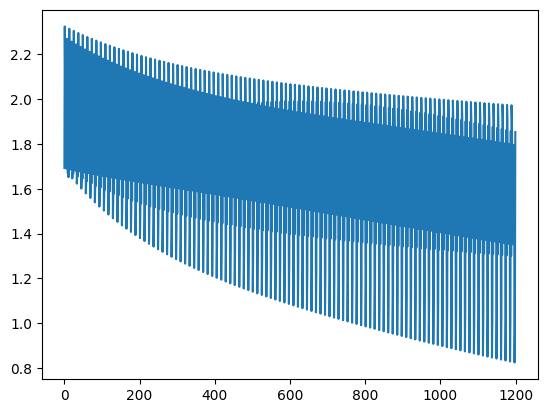

In [78]:
import matplotlib.pyplot as plt

plt.plot(history['loss'])
plt.show()